In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1 Data Familiarization and Clearning
df=pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [5]:
df.dropna(subset=["date_added"],inplace=True)


In [6]:
df.isna().sum()

show_id            0
type               0
title              0
director        1958
cast             569
country          474
date_added         0
release_year       0
rating             9
duration           0
listed_in          0
description        0
dtype: int64

In [7]:
df[['director','cast']]=df[['director','cast']].fillna({
    'director':'Unknown',
    'cast':'No information'
})
df.isna().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         474
date_added        0
release_year      0
rating            9
duration          0
listed_in         0
description       0
dtype: int64

In [8]:
mode_value=df['country'].mode()[0]
df['country']= df['country'].fillna(mode_value)
# if you want the llm must provide the right answer in any situation then you should use unknown

In [9]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          9
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
mode_value=df['rating'].mode()[0]
df['rating']=df['rating'].fillna(mode_value)

In [11]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
df.groupby('duration').mean(numeric_only=True).head(10)

,show_id,release_year
duration,,
1 Season,7.964641e+07,2015.440575
10 Seasons,7.521080e+07,1984.500000
10 min,8.117619e+07,2019.000000
100 min,7.661871e+07,2013.400000
101 min,7.525308e+07,2011.169014
102 min,7.446673e+07,2013.121622
103 min,7.526565e+07,2011.800000
104 min,7.599454e+07,2012.306452
105 min,7.549409e+07,2013.728571


In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], format = 'mixed')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [14]:
# parse and clean columns
# using single \ it can be fall into special charactor
# use \\ or use r 
# using r means row data that is safest and good practice
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,90.0
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,94.0
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",1.0
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,1.0
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,99.0


In [16]:
print(df["date_added"].dtype)

datetime64[us]


In [17]:
from datetime import datetime

In [18]:
current_year = datetime.now().year

In [19]:
df['content_age']=current_year-df['release_year']
print(df['content_age'])

0        7
1       10
2       13
3       10
4        9
        ..
6218     9
6219     7
6220    14
6221    10
6222    14
Name: content_age, Length: 6223, dtype: int64


In [20]:
# if you want to calculate all things like the days and times 
current_date=pd.Timestamp.now()
print(current_date)

2026-06-08 22:29:16.736443


In [21]:
df['days_since_added'] = current_date - df['date_added']
df['year_since_added']=(current_date-df['date_added']).dt.days/365.25
print(df['year_since_added'])

0        6.746064
1        9.744011
2        7.748118
3        7.748118
4        8.747433
          ...    
6218     7.162218
6219     7.186858
6220    10.184805
6221    10.184805
6222    12.186174
Name: year_since_added, Length: 6223, dtype: float64


In [22]:
from sklearn.preprocessing import StandardScaler, Normalizer

In [23]:
# Section 2: Feature Engineering

df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
numeric_cols = ['duration_num', 'content_age']
X = df[numeric_cols].dropna()
print('this is df','this is dur',df['duration_num'],'this is nu col',numeric_cols,'this is drop',X)

this is df this is dur 0       90.0
1       94.0
2        1.0
3        1.0
4       99.0
        ... 
6218     2.0
6219     2.0
6220     2.0
6221     2.0
6222     8.0
Name: duration_num, Length: 6223, dtype: float64 this is nu col ['duration_num', 'content_age'] this is drop       duration_num  content_age
0             90.0            7
1             94.0           10
2              1.0           13
3              1.0           10
4             99.0            9
...            ...          ...
6218           2.0            9
6219           2.0            7
6220           2.0           14
6221           2.0           10
6222           8.0           14

[6223 rows x 2 columns]


In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,90.0,7,2464 days 22:29:16.736443,6.746064
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,94.0,10,3559 days 22:29:16.736443,9.744011
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",1.0,13,2830 days 22:29:16.736443,7.748118
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,1.0,10,2830 days 22:29:16.736443,7.748118
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,99.0,9,3195 days 22:29:16.736443,8.747433


In [25]:

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

df_standardized = pd.DataFrame(X_standardized, columns=numeric_cols)
print("Standardized Data (Mean ≈ 0, Std ≈ 1):\n", df_standardized.head())

Standardized Data (Mean ≈ 0, Std ≈ 1):
    duration_num  content_age
0      0.423587    -0.639497
1      0.502264    -0.299206
2     -1.326981     0.041085
3     -1.326981    -0.299206
4      0.600611    -0.412636


In [26]:
# Initialize the Normalizer
normalizer = Normalizer()
 
X_normalized = normalizer.fit_transform(X)

df_normalized = pd.DataFrame(X_normalized, columns=numeric_cols)
print("\nNormalized Data (Row vector length = 1):\n", df_normalized.head())


Normalized Data (Row vector length = 1):
    duration_num  content_age
0      0.996989     0.077544
1      0.994389     0.105786
2      0.076696     0.997054
3      0.099504     0.995037
4      0.995893     0.090536


In [27]:
from sklearn.preprocessing import MinMaxScaler

# Squeezes column values perfectly between 0 and 1
min_max_scaler = MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)

df_minmax = pd.DataFrame(X_minmax, columns=numeric_cols)
print(df_minmax)

      duration_num  content_age
0         0.286174     0.010526
1         0.299035     0.042105
2         0.000000     0.073684
3         0.000000     0.042105
4         0.315113     0.031579
...            ...          ...
6218      0.003215     0.031579
6219      0.003215     0.010526
6220      0.003215     0.084211
6221      0.003215     0.042105
6222      0.022508     0.084211

[6223 rows x 2 columns]


In [28]:
#  section 3:Univariate Analysis
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,90.0,7,2464 days 22:29:16.736443,6.746064
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,94.0,10,3559 days 22:29:16.736443,9.744011
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",1.0,13,2830 days 22:29:16.736443,7.748118
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,1.0,10,2830 days 22:29:16.736443,7.748118
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,99.0,9,3195 days 22:29:16.736443,8.747433


In [29]:
content_type=df['type'].head()
duration=df['duration'].head()
genres=df['listed_in'].head()
content_age=df['content_age'].head()
print(duration)

0      90 min
1      94 min
2    1 Season
3    1 Season
4      99 min
Name: duration, dtype: str


<Axes: xlabel='content_age', ylabel='Count'>

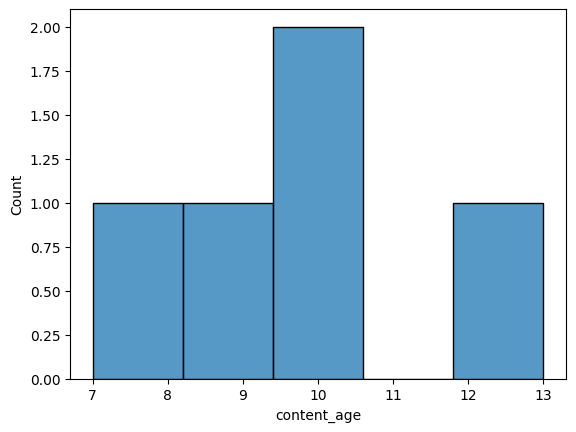

In [30]:
sns.histplot(content_age)

<Axes: xlabel='count', ylabel='duration'>

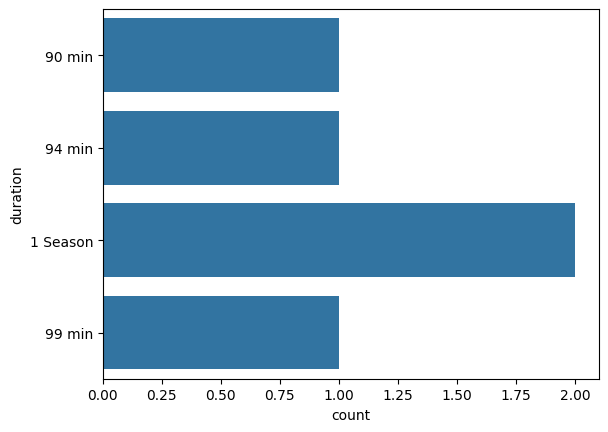

In [31]:
sns.countplot(duration)

<Axes: ylabel='listed_in'>

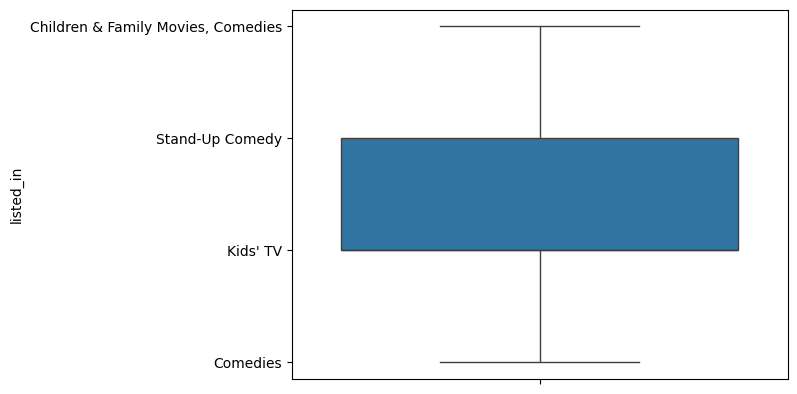

In [32]:
sns.boxplot(genres)

<Axes: ylabel='content_age'>

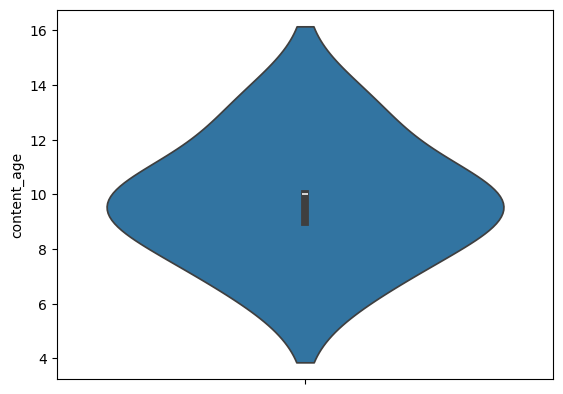

In [33]:
sns.violinplot(content_age)

In [34]:
print(df['duration_num'].mean())
print(df['duration_num'].median())
print(df['duration_num'].mode())
print(df['duration_num'].std())

68.46456692913385
87.0
0    1.0
Name: duration_num, dtype: float64
50.84472542620013


In [35]:
Q1 = df['duration_num'].quantile(0.25)

Q3 = df['duration_num'].quantile(0.75)

IQR = Q3 - Q1
print("Q1 : ",Q1,"\nQ3 : ","\nIQR : ",IQR)

Q1 :  2.0 
Q3 :  
IQR :  103.0


In [36]:
df['z_score'] = zscore(
    df['duration_num']
)

NameError: name 'zscore' is not defined

In [ ]:
from scipy.stats import median_abs_deviation
mad = median_abs_deviation(
    df['duration_num']
)

In [ ]:
median = np.median(df['duration_num'])

modified_z = 0.6745 * (
    (df['duration_num'] - median)
    / mad
)

In [ ]:
from scipy.stats import skew
skew(df['duration_num'])

np.float64(-0.1622366406520895)

In [ ]:
genre_duration = df.groupby(
    'listed_in'
)['duration_num'].mean()

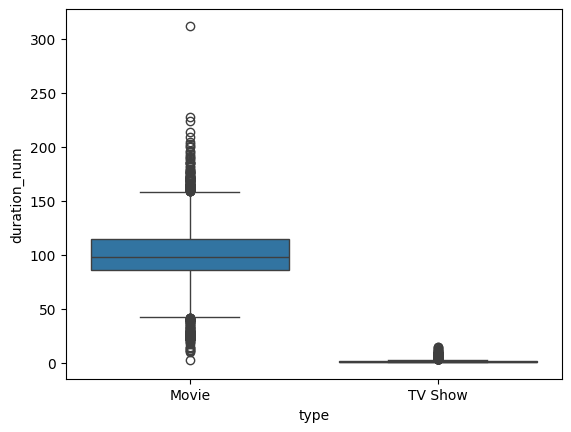

In [ ]:
sns.boxplot(
    x='type',
    y='duration_num',
    data=df
)
plt.show()

<Axes: xlabel='type', ylabel='content_age'>

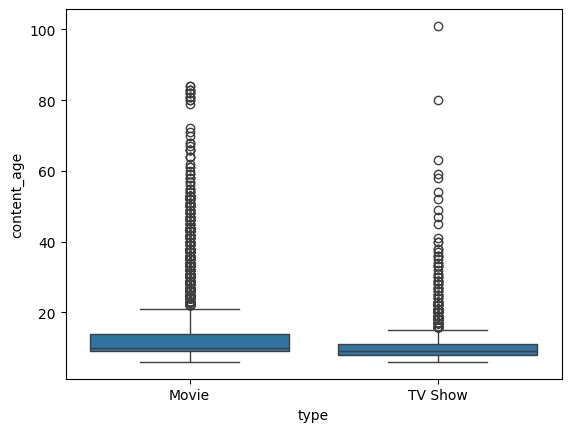

In [ ]:
sns.boxplot(
    x='type',
    y='content_age',
    data=df
)

In [ ]:
pd.crosstab(
    df['country'],
    df['type']
)

type,Movie,TV Show
country,,
Argentina,26,12
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0
...,...,...
"Uruguay, Spain, Mexico",1,0
Venezuela,1,0
"Venezuela, Colombia",1,0


<Axes: xlabel='content_age', ylabel='duration_num'>

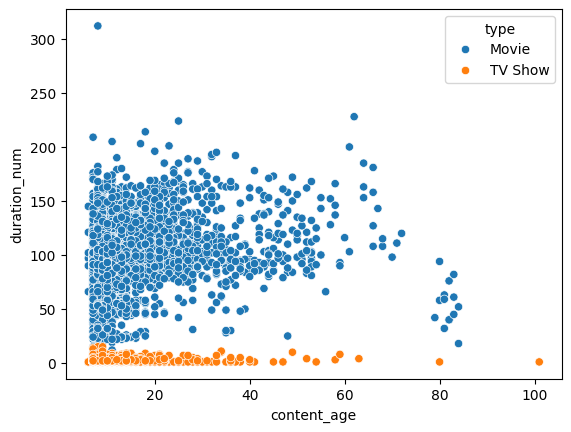

In [ ]:
sns.scatterplot(
    x='content_age',
    y='duration_num',
    hue='type',
    data=df
)

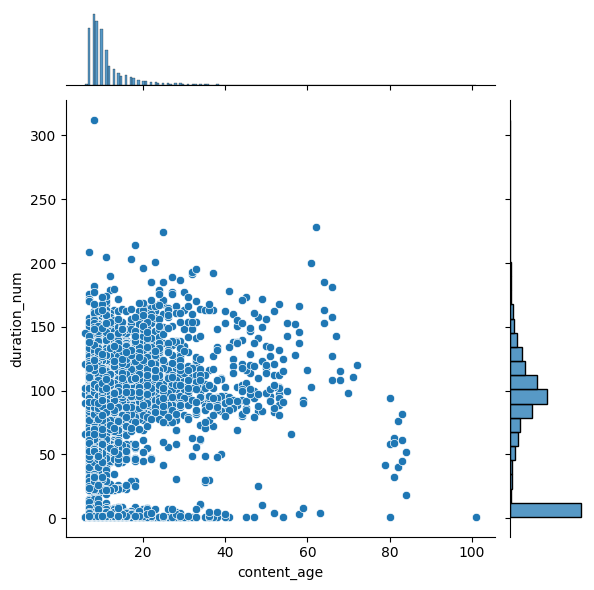

In [ ]:
sns.jointplot(
    x='content_age',
    y='duration_num',
    data=df
)

In [ ]:
pivot = pd.pivot_table(
    df,
    index='release_year',
    columns='type',
    values='show_id',
    aggfunc='count'
)
pivot

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,NaN
...,...,...
2016,592.0,236.0
2017,682.0,277.0
2018,646.0,416.0


<Axes: >

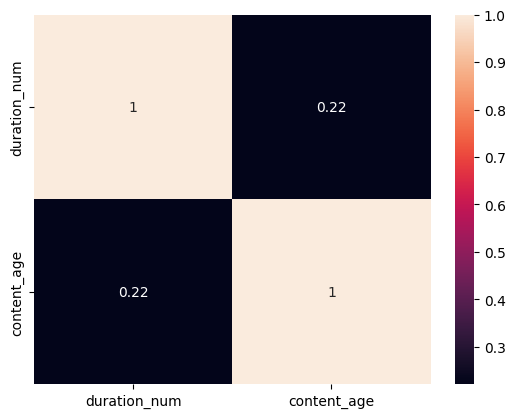

In [ ]:
corr = df[
    ['duration_num',
     'content_age']
].corr()

sns.heatmap(
    corr,
    annot=True
)

In [ ]:
outliers = df[
    np.abs(
        zscore(df['duration_num'])
    ) > 3
]
outliers

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added,z_score
4106,60020906,Movie,Lagaan,Ashutosh Gowariker,"Aamir Khan, Gracy Singh, Rachel Shelley, Paul ...",India,2017-12-08,2001,PG,224 min,"Dramas, International Movies, Music & Musicals","In 1890s India, an arrogant British commander ...",224.0,25,3104 days 22:22:40.797935,8.498289,3.059274
4227,60002818,Movie,Sangam,Raj Kapoor,"Raj Kapoor, Vyjayanthimala, Rajendra Kumar, La...",India,2019-12-31,1964,TV-14,228 min,"Classic Movies, Dramas, International Movies",Returning home from war after being assumed de...,228.0,62,2351 days 22:22:40.797935,6.436687,3.137951
4315,80988062,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312.0,8,2719 days 22:22:40.797935,7.444216,4.790172


In [ ]:
lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers_iqr = df[
    (df['duration_num'] < lower)
    |
    (df['duration_num'] > upper)
]
print(lower)
print(upper)
print(outliers)

-152.5
259.5
       show_id   type                       title            director  \
4106  60020906  Movie                      Lagaan  Ashutosh Gowariker   
4227  60002818  Movie                      Sangam          Raj Kapoor   
4315  80988062  Movie  Black Mirror: Bandersnatch             Unknown   

                                                   cast        country  \
4106  Aamir Khan, Gracy Singh, Rachel Shelley, Paul ...          India   
4227  Raj Kapoor, Vyjayanthimala, Rajendra Kumar, La...          India   
4315  Fionn Whitehead, Will Poulter, Craig Parkinson...  United States   

     date_added  release_year rating duration  \
4106 2017-12-08          2001     PG  224 min   
4227 2019-12-31          1964  TV-14  228 min   
4315 2018-12-28          2018  TV-MA  312 min   

                                           listed_in  \
4106  Dramas, International Movies, Music & Musicals   
4227    Classic Movies, Dramas, International Movies   
4315  Dramas, International Movi

In [ ]:
outliers_iqr.sort_values(
    by='duration_num',
    ascending=False
).head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added,z_score
4315,80988062,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312.0,8,2719 days 22:22:40.797935,7.444216,4.790172


In [ ]:
pakistan = df[
    df['country'].str.contains(
        "Pakistan",
        na=False
    )
].head()
pakistan

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added,z_score
55,81160036,Movie,Saawan,Farhan Alam,"Karam Hussain, Arif Bahlim, Najiba Faiz, Salee...",Pakistan,2019-09-04,2016,TV-14,128 min,"Dramas, Independent Movies, International Movies",Outcast from society and left to die in the wi...,128.0,10,2469 days 22:22:40.797935,6.759754,1.171021
243,80142637,Movie,Janaan,Azfar Jafri,"Armeena Rana Khan, Bilal Ashraf, Ali Rehman Kh...",Pakistan,2017-09-15,2016,TV-14,132 min,"Comedies, Dramas, International Movies","After 11 years in Canada, young Meena returns ...",132.0,10,3188 days 22:22:40.797935,8.728268,1.249698
404,80114155,Movie,Dukhtar,Afia Nathaniel,"Samiya Mumtaz, Mohib Mirza, Saleha Aref, Asif ...","Pakistan, Norway, United States",2016-09-01,2014,TV-14,93 min,"Dramas, Independent Movies, International Movies",A young mother embarks on a desperate quest fo...,93.0,12,3567 days 22:22:40.797935,9.765914,0.482595
919,81024705,Movie,Zindagi Kitni Haseen Hay,Anjum Shahzad,"Feroze Khan, Sajal Ali, Jibrayl Ahmed Rajput, ...",Pakistan,2018-10-01,2016,TV-14,126 min,"Dramas, International Movies, Romantic Movies",Two young parents struggle to keep their marri...,126.0,10,2807 days 22:22:40.797935,7.685147,1.131682
1505,80080145,Movie,Moor,Jami,"Hameed Sheikh, Samiya Mumtaz, Shaz Khan, Abdul...","Pakistan, United States",2017-11-01,2015,TV-14,135 min,"Dramas, Independent Movies, International Movies",A railway stationmaster tries to cope with his...,135.0,11,3141 days 22:22:40.797935,8.599589,1.308706


In [ ]:
shows = df[
    (df['type']=="TV Show")
    &
    (df['duration_num'] > 3)
]
shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added,z_score
5584,70270745,TV Show,Ripper Street,Unknown,"Matthew Macfadyen, Jerome Flynn, Adam Rothenbe...","United Kingdom, Ireland",2017-09-08,2017,TV-MA,5 Seasons,"British TV Shows, Crime TV Shows, TV Dramas",It's been six months since the last Jack the R...,5.0,9,3195 days 22:22:40.797935,8.747433,-1.248304
5585,70177067,TV Show,Haven,Unknown,"Emily Rose, Lucas Bryant, Nicholas Campbell, E...","Canada, United States",2015-09-08,2015,TV-14,5 Seasons,"Classic & Cult TV, TV Horror, TV Mysteries","Residents of Haven, Maine, are plagued by supe...",5.0,11,3926 days 22:22:40.797935,10.748802,-1.248304
5591,70197049,TV Show,Once Upon a Time,"Mario Van Peebles, Ralph Hemecker, Gwyneth Hor...","Lana Parrilla, Robert Carlyle, Jared Gilmore, ...",United States,2018-09-06,2018,TV-PG,7 Seasons,"TV Dramas, TV Sci-Fi & Fantasy","In this fantasy series, a young woman is drawn...",7.0,8,2832 days 22:22:40.797935,7.753593,-1.208965
5592,70283260,TV Show,Reign,Unknown,"Adelaide Kane, Megan Follows, Torrance Coombs,...",United States,2017-09-05,2017,TV-14,4 Seasons,TV Dramas,This vivid historical drama series tells of th...,4.0,9,3198 days 22:22:40.797935,8.755647,-1.267973
5593,70143860,TV Show,The Vampire Diaries,Unknown,"Nina Dobrev, Paul Wesley, Ian Somerhalder, Ste...",United States,2017-09-04,2017,TV-14,8 Seasons,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy","Trapped in adolescent bodies, feuding vampire ...",8.0,9,3199 days 22:22:40.797935,8.758385,-1.189296


In [ ]:
movies = df[
    (df['type']=="Movie")
    &
    (df['duration_num'] > 150)
]
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,content_age,days_since_added,year_since_added,z_score
96,81002866,Movie,The Sinking Of Van Der Wijck,Sunil Soraya,"Herjunot Ali, Pevita Pearce, Reza Rahadian, Ra...",Indonesia,2018-09-28,2013,TV-14,163 min,"Dramas, International Movies, Romantic Movies",When a young man leaves home to fulfill the wi...,163.0,13,2810 days 22:22:40.797935,7.693361,1.859446
130,81176200,Movie,Manmadhudu 2,Rahul Ravindran,"Nagarjuna Akkineni, Rakul Preet Singh, Lakshmi...",India,2019-09-23,2019,TV-MA,152 min,"Comedies, Dramas, International Movies","Under pressure to marry, a perennial bachelor ...",152.0,7,2450 days 22:22:40.797935,6.707734,1.643084
142,81172721,Movie,King of Boys,Kemi Adetiba,"Sola Sobowale, Adesua Etomi, Remilekun Safaru,...",Nigeria,2019-09-21,2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...,182.0,8,2452 days 22:22:40.797935,6.713210,2.233163
177,81107545,Movie,Kabir Singh,Sandeep Reddy Vanga,"Shahid Kapoor, Kiara Advani, Suresh Oberoi, Ar...",India,2019-09-19,2019,TV-MA,171 min,"Dramas, International Movies, Romantic Movies",An exalted but short-fused surgeon plunges int...,171.0,7,2454 days 22:22:40.797935,6.718686,2.016801
229,81018233,Movie,Eeda,Ajithkumar,"Shane Nigaam, Nimisha Sajayan, Manikandan R. A...",India,2018-09-15,2018,TV-14,153 min,"Dramas, International Movies, Romantic Movies",Two young adults with families on opposite end...,153.0,8,2823 days 22:22:40.797935,7.728953,1.662753


In [ ]:
df['director'].value_counts().head(5)

director
Unknown                   1958
Raúl Campos, Jan Suter      18
Marcus Raboy                14
Jay Karas                   13
Jay Chapman                 12
Name: count, dtype: int64

In [ ]:
actors = (
    df['cast']
    .str.split(',')
    .explode()
)

actors.value_counts().head(5)

cast
No information       569
 Anupam Kher          30
 Om Puri              25
 Takahiro Sakurai     24
Shah Rukh Khan        24
Name: count, dtype: int64